In [1]:
!pip install transformers torch scikit-learn pandas mlflow -q

import mlflow
import mlflow.pytorch
import pandas as pd
import torch
from transformers import DebertaV2Tokenizer, DebertaV2ForSequenceClassification
from torch.utils.data import DataLoader, TensorDataset, RandomSampler, SequentialSampler
from torch.optim import AdamW
from sklearn.model_selection import GroupShuffleSplit
from sklearn.utils import shuffle
from sklearn.metrics import (accuracy_score, f1_score, precision_score,
                             recall_score, confusion_matrix, classification_report)

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
import os

# Then list the contents of the AI_Detector folder
print(os.listdir('/content/drive/My Drive/AI_Text_Detector(revamp)'))


['saved_models', 'Notebook', 'Dataset']


Load and Clean Data

In [4]:
import pandas as pd

# ── Load original dataset ────────────────────────────────────────────────
dataset_path = "/content/drive/My Drive/AI_Text_Detector(revamp)/Dataset/Training_Essay_Data.csv"
df = pd.read_csv(dataset_path)
print(f"Original: {len(df)} rows")

# ── Clean ────────────────────────────────────────────────────────────────
df = df.drop_duplicates(subset='text')
df = df[~df['text'].str.contains(r'\[Your Name\]', regex=True)]
print(f"After cleaning: {len(df)} rows")

# Load Deep Essays
deep_essays = pd.read_csv("/content/drive/My Drive/AI_Text_Detector(revamp)/Dataset/essays_human.csv")
deep_essays = deep_essays[['essay']].rename(columns={'essay': 'text'}).dropna()
deep_essays = deep_essays.drop_duplicates(subset='text').reset_index(drop=True)
print(f"Deep Essays total: {len(deep_essays)} rows")

# Clean split — 200 OOD first, then 1000 for training
deep_ood_portion   = deep_essays.sample(200, random_state=42)
remaining          = deep_essays.drop(deep_ood_portion.index)
deep_train_portion = remaining.sample(1000, random_state=42)

# Verify no overlap
overlap = set(deep_ood_portion['text'].values).intersection(set(deep_train_portion['text'].values))
print(f"Overlap between OOD and train portions: {len(overlap)}")  # must be 0

# Save OOD portion immediately before anything else touches it
deep_ood_portion.to_csv("/content/drive/My Drive/AI_Text_Detector(revamp)/Dataset/deep_essays_ood.csv", index=False)
print(f"OOD portion saved: {len(deep_ood_portion)} rows")
print(f"Train portion: {len(deep_train_portion)} rows")

# Add to main dataset
deep_train_df = pd.DataFrame({
    'text':      deep_train_portion['text'].values,
    'generated': 0
})

df = pd.concat([df, deep_train_df]).reset_index(drop=True)
print(f"Augmented dataset: {len(df)} rows")
print(df['generated'].value_counts())

Original: 29145 rows
After cleaning: 26679 rows
Deep Essays total: 2235 rows
Overlap between OOD and train portions: 0
OOD portion saved: 200 rows
Train portion: 1000 rows
Augmented dataset: 27679 rows
generated
0    17122
1    10557
Name: count, dtype: int64


Topic Grouping and Proper Split

In [5]:
def assign_topic(text):
    t = text.lower()
    if 'car-free' in t or 'car free' in t:            return 'car_free'
    if 'electoral college' in t:                       return 'electoral'
    if 'facial recognition' in t:                      return 'facial_rec'
    if 'driverless' in t or 'self-driving' in t:       return 'driverless'
    if 'venus' in t:                                   return 'venus'
    if 'social media' in t:                            return 'social_media'
    if 'climate change' in t or 'global warming' in t: return 'climate'
    if 'school uniform' in t:                          return 'uniforms'
    if 'phone' in t or 'smartphone' in t:              return 'phones'
    if 'immigration' in t or 'immigrant' in t:         return 'immigration'
    return 'other'

df['topic'] = df['text'].apply(assign_topic)

# Sanity check — confirm deep essays landed in other
print("Topic distribution:")
print(df.groupby(['topic', 'generated']).size().unstack(fill_value=0))

# Topic-grouped split
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(df, df['generated'], groups=df['topic']))

# Check the split looks reasonable
print(f"Train: {len(train_idx)}, Test: {len(test_idx)}")
print(f"Test is {len(test_idx)/len(df)*100:.1f}% of data")

train_df = df.iloc[train_idx].drop(columns='topic').reset_index(drop=True)
test_df  = df.iloc[test_idx].drop(columns='topic').reset_index(drop=True)

# If test set is under 15% or heavily imbalanced, fall back to stratified split
if len(test_df) < len(df) * 0.15 or test_df['generated'].value_counts().min() < 800:
    print("Group split too uneven — using stratified split instead")
    from sklearn.model_selection import train_test_split
    train_df, test_df = train_test_split(
        df.drop(columns='topic'),
        test_size=0.2,
        random_state=42,
        stratify=df['generated']  # ensures balanced class ratio in test
    )

# Balance only training set
human_train = train_df[train_df['generated'] == 0]
ai_train    = train_df[train_df['generated'] == 1]
min_count   = min(len(human_train), len(ai_train))

train_df = pd.concat([
    human_train.sample(n=min_count, random_state=42),
    ai_train.sample(n=min_count, random_state=42)
])
train_df = shuffle(train_df, random_state=42).reset_index(drop=True)

print(f"Train: {len(train_df)} rows")
print(f"Test:  {len(test_df)} rows")
print(f"\nTrain distribution:\n{train_df['generated'].value_counts()}")
print(f"\nTest distribution:\n{test_df['generated'].value_counts()}")

Topic distribution:
generated        0     1
topic                   
car_free      1098   383
climate        221   380
driverless      15    89
electoral     2533   103
facial_rec      73    49
immigration     70    25
other         9296  8319
phones        1531   477
social_media   407   591
uniforms         1    11
venus         1877   130
Train: 26091, Test: 1588
Test is 5.7% of data
Group split too uneven — using stratified split instead
Train: 16892 rows
Test:  5536 rows

Train distribution:
generated
1    8446
0    8446
Name: count, dtype: int64

Test distribution:
generated
0    3425
1    2111
Name: count, dtype: int64


Tokenizer

In [6]:
from transformers import RobertaTokenizer
from torch.utils.data import DataLoader, TensorDataset, RandomSampler, SequentialSampler

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

tokenizer = RobertaTokenizer.from_pretrained("roberta-base")

def tokenize_texts(texts, max_length=512):
    return tokenizer(
        texts.tolist(),
        padding="max_length",
        truncation=True,
        max_length=max_length,
        return_tensors="pt"
    )

train_encodings = tokenize_texts(train_df['text'])
test_encodings  = tokenize_texts(test_df['text'])

train_labels = torch.tensor(train_df['generated'].values)
test_labels  = torch.tensor(test_df['generated'].values)

batch_size = 16
train_data       = TensorDataset(train_encodings['input_ids'], train_encodings['attention_mask'], train_labels)
train_dataloader = DataLoader(train_data, sampler=RandomSampler(train_data), batch_size=batch_size)

test_data       = TensorDataset(test_encodings['input_ids'], test_encodings['attention_mask'], test_labels)
test_dataloader = DataLoader(test_data, sampler=SequentialSampler(test_data), batch_size=batch_size)

print(f"Train batches: {len(train_dataloader)}")
print(f"Test batches:  {len(test_dataloader)}")

Using device: cuda


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Train batches: 1056
Test batches:  346


Load Model

In [7]:
from transformers import RobertaForSequenceClassification
from transformers import get_linear_schedule_with_warmup
from torch.optim import AdamW

epochs = 4

model = RobertaForSequenceClassification.from_pretrained(
    "roberta-base",
    num_labels=2,
    hidden_dropout_prob=0.1,
    attention_probs_dropout_prob=0.1
)
model.to(device)

optimizer = AdamW(model.parameters(), lr=2e-5, eps=1e-8)

total_steps = len(train_dataloader) * epochs

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=total_steps // 10,
    num_training_steps=total_steps
)

# Early stopping variables
best_f1 = 0
patience = 1
patience_counter = 0

print("Model loaded successfully")
print(f"Total steps: {total_steps}")

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
classifier.dense.bias           | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.out_proj.weight      | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model loaded successfully
Total steps: 4224


MLFLow setup

In [8]:
mlflow.set_experiment("ai-text-detector")

<Experiment: artifact_location='/content/mlruns/1', creation_time=1775548912272, experiment_id='1', last_update_time=1775548912272, lifecycle_stage='active', name='ai-text-detector', tags={}, workspace='default'>

Sanity Check

In [9]:
model.eval()
with torch.no_grad():
    sample_batch = next(iter(train_dataloader))
    b_ids, b_mask, b_labels = tuple(t.to(device) for t in sample_batch)
    outputs = model(b_ids, attention_mask=b_mask, labels=b_labels)
    print(f"Sample loss: {outputs.loss.item():.6f}")
    print(f"Is NaN: {torch.isnan(outputs.loss)}")

Sample loss: 0.689779
Is NaN: False


Training Loop

In [10]:
import gc
torch.cuda.empty_cache()
gc.collect()

scaler = torch.amp.GradScaler('cuda')

with mlflow.start_run(run_name="roberta-base"):

    mlflow.log_params({
        "model_name":    "roberta-base",
        "epochs":        4,
        "batch_size":    16,
        "learning_rate": 2e-5,
        "max_length":    512,
        "dropout":       0.1,
        "train_size":    len(train_df),
        "test_size":     len(test_df),
        "scheduler":     "linear_with_warmup",
        "warmup_steps":  total_steps // 10,
        "patience":      1,
    })

    epochs = 4
    for epoch in range(epochs):
        model.train()
        total_loss = 0
        nan_count  = 0

        for step, batch in enumerate(train_dataloader):
            b_input_ids, b_input_mask, b_labels = tuple(t.to(device) for t in batch)
            model.zero_grad()

            with torch.amp.autocast('cuda'):
                outputs = model(b_input_ids, attention_mask=b_input_mask, labels=b_labels)
                loss = outputs.loss

            if torch.isnan(loss) or torch.isinf(loss):
                nan_count += 1
                continue

            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()
            scheduler.step()

            total_loss += loss.item()
            if step % 100 == 0:
                print(f"Epoch {epoch+1}, Step {step}, Loss: {loss.item():.6f}")

        avg_loss = total_loss / len(train_dataloader)
        print(f"Epoch {epoch+1}, Avg Loss: {avg_loss:.6f} | NaN skipped: {nan_count}")
        mlflow.log_metric("train_loss", avg_loss, step=epoch)
        mlflow.log_metric("nan_batches", nan_count, step=epoch)

        # ── Evaluate after each epoch ────────────────────────────
        model.eval()
        epoch_preds, epoch_labels = [], []

        with torch.no_grad():
            for batch in test_dataloader:
                b_input_ids, b_input_mask, b_labels = tuple(t.to(device) for t in batch)
                outputs = model(b_input_ids, attention_mask=b_input_mask)
                epoch_preds.extend(torch.argmax(outputs.logits, dim=1).cpu().numpy())
                epoch_labels.extend(b_labels.cpu().numpy())

        epoch_f1  = f1_score(epoch_labels, epoch_preds, average='weighted')
        epoch_acc = accuracy_score(epoch_labels, epoch_preds)
        print(f"Epoch {epoch+1} — Val Accuracy: {epoch_acc:.4f} | Val F1: {epoch_f1:.4f}")
        print(classification_report(epoch_labels, epoch_preds, target_names=['Human', 'AI-Generated']))

        mlflow.log_metric("val_f1",      epoch_f1,  step=epoch)
        mlflow.log_metric("val_accuracy", epoch_acc, step=epoch)

        # ── Save best model ──────────────────────────────────────
        if epoch_f1 > best_f1:
            best_f1 = epoch_f1
            torch.save(model.state_dict(), "best_model.pt")
            print(f"New best model saved — F1: {best_f1:.4f}")
            patience_counter = 0
        else:
            patience_counter += 1
            print(f"No improvement — patience {patience_counter}/{patience}")
            if patience_counter >= patience:
                print("Early stopping triggered")
                mlflow.log_param("stopped_at_epoch", epoch + 1)
                break

        model.train()

    mlflow.log_param("best_f1", best_f1)
    print(f"\nTraining complete — Best F1: {best_f1:.4f}")

Epoch 1, Step 0, Loss: 0.706055
Epoch 1, Step 100, Loss: 0.375885
Epoch 1, Step 200, Loss: 0.005432
Epoch 1, Step 300, Loss: 0.001175
Epoch 1, Step 400, Loss: 0.003386
Epoch 1, Step 500, Loss: 0.000223
Epoch 1, Step 600, Loss: 0.000197
Epoch 1, Step 700, Loss: 0.004038
Epoch 1, Step 800, Loss: 0.217099
Epoch 1, Step 900, Loss: 0.000185
Epoch 1, Step 1000, Loss: 0.000115
Epoch 1, Avg Loss: 0.097179 | NaN skipped: 0
Epoch 1 — Val Accuracy: 0.9836 | Val F1: 0.9836
              precision    recall  f1-score   support

       Human       1.00      0.97      0.99      3425
AI-Generated       0.96      1.00      0.98      2111

    accuracy                           0.98      5536
   macro avg       0.98      0.99      0.98      5536
weighted avg       0.98      0.98      0.98      5536

New best model saved — F1: 0.9836
Epoch 2, Step 0, Loss: 0.000074
Epoch 2, Step 100, Loss: 0.000070
Epoch 2, Step 200, Loss: 0.000086
Epoch 2, Step 300, Loss: 0.000055
Epoch 2, Step 400, Loss: 0.000052
Epoch

Evaluation

In [11]:
# Load the best saved checkpoint
model.load_state_dict(torch.load("best_model.pt"))
model.eval()

predictions, true_labels = [], []

with torch.no_grad():
    for batch in test_dataloader:
        b_input_ids, b_input_mask, b_labels = tuple(t.to(device) for t in batch)
        outputs = model(b_input_ids, attention_mask=b_input_mask)
        predictions.extend(torch.argmax(outputs.logits, dim=1).cpu().numpy())
        true_labels.extend(b_labels.cpu().numpy())

acc       = accuracy_score(true_labels, predictions)
f1        = f1_score(true_labels, predictions, average='weighted')
precision = precision_score(true_labels, predictions, average='weighted')
recall    = recall_score(true_labels, predictions, average='weighted')

print(f"Final Accuracy:  {acc:.4f}")
print(f"Final F1:        {f1:.4f}")
print(f"Final Precision: {precision:.4f}")
print(f"Final Recall:    {recall:.4f}")
print(f"\nConfusion Matrix:\n{confusion_matrix(true_labels, predictions)}")
print(f"\n{classification_report(true_labels, predictions, target_names=['Human', 'AI-Generated'])}")

Final Accuracy:  0.9987
Final F1:        0.9987
Final Precision: 0.9987
Final Recall:    0.9987

Confusion Matrix:
[[3425    0]
 [   7 2104]]

              precision    recall  f1-score   support

       Human       1.00      1.00      1.00      3425
AI-Generated       1.00      1.00      1.00      2111

    accuracy                           1.00      5536
   macro avg       1.00      1.00      1.00      5536
weighted avg       1.00      1.00      1.00      5536



OOD Test

In [12]:
import pandas as pd
from sklearn.metrics import (accuracy_score, f1_score, precision_score,
                             recall_score, classification_report, confusion_matrix)

# ── Load OOD datasets ────────────────────────────────────────────────────
human_ood = pd.read_csv("/content/drive/My Drive/AI_Text_Detector(revamp)/Dataset/essays_human.csv")
ai_ood    = pd.read_csv("/content/drive/My Drive/AI_Text_Detector(revamp)/Dataset/essays_ai.csv")

# ── Sample 200 from each for balanced evaluation ─────────────────────────
human_ood = human_ood[['essay']].rename(columns={'essay': 'text'}).sample(200, random_state=42)
ai_ood    = ai_ood[['text']]

human_ood['label'] = 0
ai_ood['label']    = 1

ood_df = pd.concat([human_ood, ai_ood]).reset_index(drop=True)
print(f"OOD dataset: {len(ood_df)} rows")
print(ood_df['label'].value_counts())

# ── Tokenize ─────────────────────────────────────────────────────────────
ood_encodings = tokenizer(
    ood_df['text'].tolist(),
    padding="max_length",
    truncation=True,
    max_length=512,
    return_tensors="pt"
)

ood_labels = torch.tensor(ood_df['label'].values)

ood_data       = TensorDataset(ood_encodings['input_ids'],
                               ood_encodings['attention_mask'],
                               ood_labels)
ood_dataloader = DataLoader(ood_data, batch_size=16)

# ── Evaluate ─────────────────────────────────────────────────────────────
model.eval()
ood_preds, ood_true = [], []

with torch.no_grad():
    for batch in ood_dataloader:
        b_input_ids, b_input_mask, b_labels = tuple(t.to(device) for t in batch)
        outputs = model(b_input_ids, attention_mask=b_input_mask)
        ood_preds.extend(torch.argmax(outputs.logits, dim=1).cpu().numpy())
        ood_true.extend(b_labels.cpu().numpy())

print("\n===== OOD EVALUATION RESULTS =====")
print(f"Accuracy:  {accuracy_score(ood_true, ood_preds):.4f}")
print(f"F1:        {f1_score(ood_true, ood_preds, average='weighted'):.4f}")
print(f"Precision: {precision_score(ood_true, ood_preds, average='weighted'):.4f}")
print(f"Recall:    {recall_score(ood_true, ood_preds, average='weighted'):.4f}")
print(f"\nConfusion Matrix:\n{confusion_matrix(ood_true, ood_preds)}")
print(f"\n{classification_report(ood_true, ood_preds, target_names=['Human', 'AI-Generated'])}")

OOD dataset: 400 rows
label
0    200
1    200
Name: count, dtype: int64

===== OOD EVALUATION RESULTS =====
Accuracy:  0.9850
F1:        0.9850
Precision: 0.9854
Recall:    0.9850

Confusion Matrix:
[[200   0]
 [  6 194]]

              precision    recall  f1-score   support

       Human       0.97      1.00      0.99       200
AI-Generated       1.00      0.97      0.98       200

    accuracy                           0.98       400
   macro avg       0.99      0.98      0.98       400
weighted avg       0.99      0.98      0.98       400



In [16]:
train_texts = set(train_df['text'].str.strip().values)
ood_human_texts = set(human_ood['text'].str.strip().values)

overlap = train_texts.intersection(ood_human_texts)
print(f"Overlapping texts between train and OOD human: {len(overlap)}")
print(f"OOD human total: {len(ood_human_texts)}")

Overlapping texts between train and OOD human: 0
OOD human total: 200


ML Flow

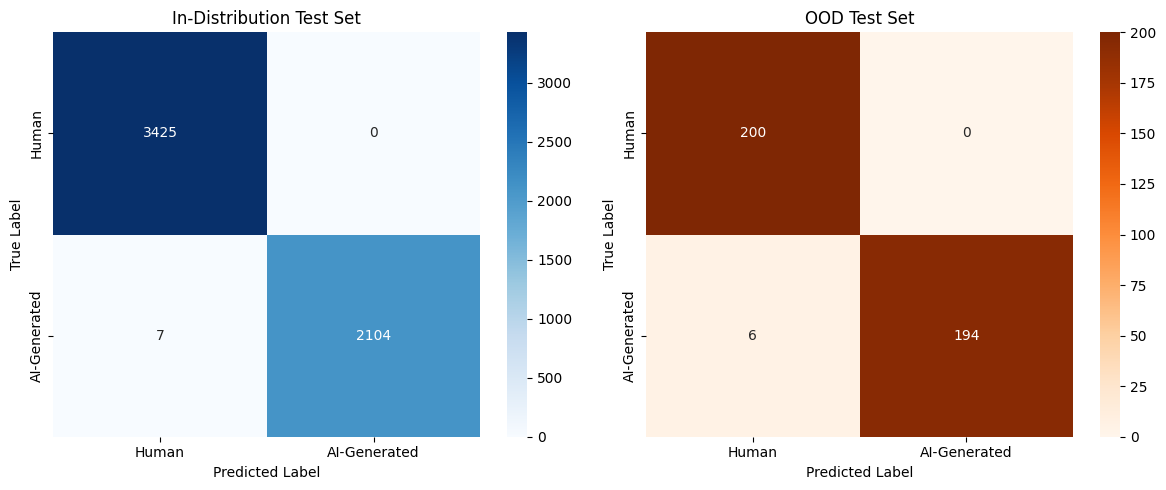

Confusion matrices logged to MLflow


In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# In-distribution confusion matrix
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# In-distribution
cm_ind = confusion_matrix(true_labels, predictions)
sns.heatmap(cm_ind, annot=True, fmt='d', ax=axes[0],
            xticklabels=['Human', 'AI-Generated'],
            yticklabels=['Human', 'AI-Generated'],
            cmap='Blues')
axes[0].set_title('In-Distribution Test Set')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

# OOD confusion matrix
cm_ood = confusion_matrix(ood_true, ood_preds)
sns.heatmap(cm_ood, annot=True, fmt='d', ax=axes[1],
            xticklabels=['Human', 'AI-Generated'],
            yticklabels=['Human', 'AI-Generated'],
            cmap='Oranges')
axes[1].set_title('OOD Test Set')
axes[1].set_ylabel('True Label')
axes[1].set_xlabel('Predicted Label')

plt.tight_layout()
plt.savefig("confusion_matrices.png", dpi=150, bbox_inches='tight')
plt.show()

# Log to MLflow
with mlflow.start_run(run_name="final-evaluation", nested=True):
    # Log in-distribution metrics
    mlflow.log_metrics({
        "test_accuracy":  accuracy_score(true_labels, predictions),
        "test_f1":        f1_score(true_labels, predictions, average='weighted'),
        "test_precision": precision_score(true_labels, predictions, average='weighted'),
        "test_recall":    recall_score(true_labels, predictions, average='weighted'),
    })

    # Log OOD metrics
    mlflow.log_metrics({
        "ood_accuracy":  accuracy_score(ood_true, ood_preds),
        "ood_f1":        f1_score(ood_true, ood_preds, average='weighted'),
        "ood_precision": precision_score(ood_true, ood_preds, average='weighted'),
        "ood_recall":    recall_score(ood_true, ood_preds, average='weighted'),
    })

    # Log confusion matrix image
    mlflow.log_artifact("confusion_matrices.png")
    print("Confusion matrices logged to MLflow")

In [20]:
# Step 1 — Log the model to MLflow
with mlflow.start_run(run_name="model-registration"):
    mlflow.pytorch.log_model(
        model,
        artifact_path="roberta-ai-detector",
        registered_model_name="AI-Text-Detector"  # registers in one step
    )
    print("Model logged and registered successfully")

2026/04/07 10:16:00 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/07 10:16:00 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.
2026/04/07 10:16:16 WARNING mlflow.utils.requirements_utils: Found torch version (2.10.0+cu128) contains a local version label (+cu128). MLflow logged a pip requirement for this package as 'torch==2.10.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2026/04/07 10:16:45 WARNING mlflow.utils.requirements_utils: Found torchvision version (0.25.0+cu128) contains a local version label (+c

Model logged and registered successfully


Registered model 'AI-Text-Detector' already exists. Creating a new version of this model...
Created version '1' of model 'AI-Text-Detector'.


Saved Models

In [24]:
# Save the model
model.save_pretrained("/content/drive/MyDrive/AI_Text_Detector(revamp)/saved_models")
tokenizer.save_pretrained("/content/drive/MyDrive/AI_Text_Detector(revamp)/saved_models")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('/content/drive/MyDrive/AI_Text_Detector(revamp)/saved_models/tokenizer_config.json',
 '/content/drive/MyDrive/AI_Text_Detector(revamp)/saved_models/tokenizer.json')

MLFlow UI

In [26]:
import subprocess
import time
from pyngrok import ngrok

# Start MLflow UI
subprocess.Popen([
    "mlflow", "ui",
    "--port", "5000",
    "--host", "0.0.0.0"
])
time.sleep(3)

ngrok.set_auth_token("YOUR_TOKEN")

# Kill any existing tunnels first
ngrok.kill()

public_url = ngrok.connect(5000)
print(f"MLflow UI: {public_url}")

MLflow UI: NgrokTunnel: "https://nonnoumenally-tritheistical-suzette.ngrok-free.dev" -> "http://localhost:5000"


In [30]:
import mlflow
import pandas as pd

# Show all runs
runs = mlflow.search_runs(experiment_names=["ai-text-detector"])
print(runs[[
    'run_id',
    'tags.mlflow.runName',
    'metrics.val_f1',
    'metrics.val_accuracy',
    'metrics.ood_f1',
    'metrics.ood_accuracy',
    'metrics.test_f1',
    'metrics.test_accuracy',
    'params.model_name',
    'params.learning_rate',
    'params.epochs',
    'params.batch_size',
]].to_string())

                             run_id tags.mlflow.runName  metrics.val_f1  metrics.val_accuracy  metrics.ood_f1  metrics.ood_accuracy  metrics.test_f1  metrics.test_accuracy params.model_name params.learning_rate params.epochs params.batch_size
0  8fd2149290fc4e31aaf27ca2bb63f32d    final-evaluation             NaN                   NaN        0.984997                 0.985         0.998735               0.998736              None                 None          None              None
1  46ed7e8768fa4d19b9d8cb21ad5196ef  model-registration             NaN                   NaN             NaN                   NaN              NaN                    NaN              None                 None          None              None
2  1114b2b5158b45178086a60da8a60806    final-evaluation             NaN                   NaN        0.984997                 0.985         0.998735               0.998736              None                 None          None              None
3  7925ac270f004387aac47d083